# Time Series

The 4 ideas you must understand first:
1. **Stationarity**

A time series is stationary when its statistical properties — mean, variance — don't change over time. Raw stock prices are never stationary. They trend upward over years. Most models require stationarity. You'll need to transform the data to achieve it. The most common way: use daily returns instead of raw prices. (today - yesterday) / yesterday.

2. **Trend, Seasonality, Noise**

Every time series is a mix of three components. Trend is the long-term direction. Seasonality is repeating patterns at fixed intervals (every month, every quarter). Noise is random fluctuation nobody can predict. Your job as a forecaster is to model the first two and accept the third.

3. **Autocorrelation**

In regular data, row 5000 has nothing to do with row 4999. In time series, yesterday's price is the single strongest predictor of today's price. This dependency between a value and its own past is called autocorrelation. It's what makes time series special and what ARIMA is built to exploit.

4. **The train/test split is different**

In your loan model you split randomly. In time series you must never do that. You can't train on future data and test on the past — that's cheating. The split must be chronological. First 80% of dates = train. Last 20% = test. Always.

In [6]:
import sys
!{sys.executable} -m pip install yfinance pandas-datareader matplotlib statsmodels


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import os

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


# Create directory if it doesn't exist
os.makedirs('./output', exist_ok=True)

# Download Nifty 50 — 12 years of daily data
nifty = yf.download('^NSEI', start='2014-04-10', end='2026-03-10')

print("Shape:", nifty.shape)
print("\nFirst 3 rows:")
print(nifty.head(3))
print("\nLast 3 rows:")
print(nifty.tail(3))
print("\nMissing values:")
print(nifty.isnull().sum())

[*********************100%***********************]  1 of 1 completed

Shape: (2927, 5)

First 3 rows:
Price             Close         High          Low         Open  Volume
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI   ^NSEI
Date                                                                  
2014-04-10  6796.399902  6819.049805  6777.299805  6803.049805  191100
2014-04-11  6776.299805  6789.350098  6743.149902  6758.350098  140700
2014-04-15  6733.100098  6813.399902  6711.750000  6792.700195  123200

Last 3 rows:
Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2026-03-05  24765.900391  24854.199219  24529.400391  24615.949219  504300
2026-03-06  24450.449219  24700.900391  24415.750000  24656.400391  433400
2026-03-09  24028.050781  24078.150391  23697.800781  23868.050781  526900

Missing values:
Price   Ticker
Close   ^NSEI     0
High    ^NSEI     0
Low   

1. Nifty trades ~250 days a year. Over 12 years that's roughly how many rows?
- 3000
2. Why would a stock index have missing dates even though we asked for every day from 2014 to 2026?
- i guess for holidays

In [8]:
# Flatten multi-level columns
nifty.columns = nifty.columns.get_level_values(0)

# Keep only Close price — that's what we forecast
nifty = nifty[['Close']]

# Make sure index is datetime
nifty.index = pd.to_datetime(nifty.index)

print(nifty.head(3))
print(nifty.tail(3))
print(nifty.shape)
print(nifty.index.dtype)

Price             Close
Date                   
2014-04-10  6796.399902
2014-04-11  6776.299805
2014-04-15  6733.100098
Price              Close
Date                    
2026-03-05  24765.900391
2026-03-06  24450.449219
2026-03-09  24028.050781
(2927, 1)
datetime64[s]


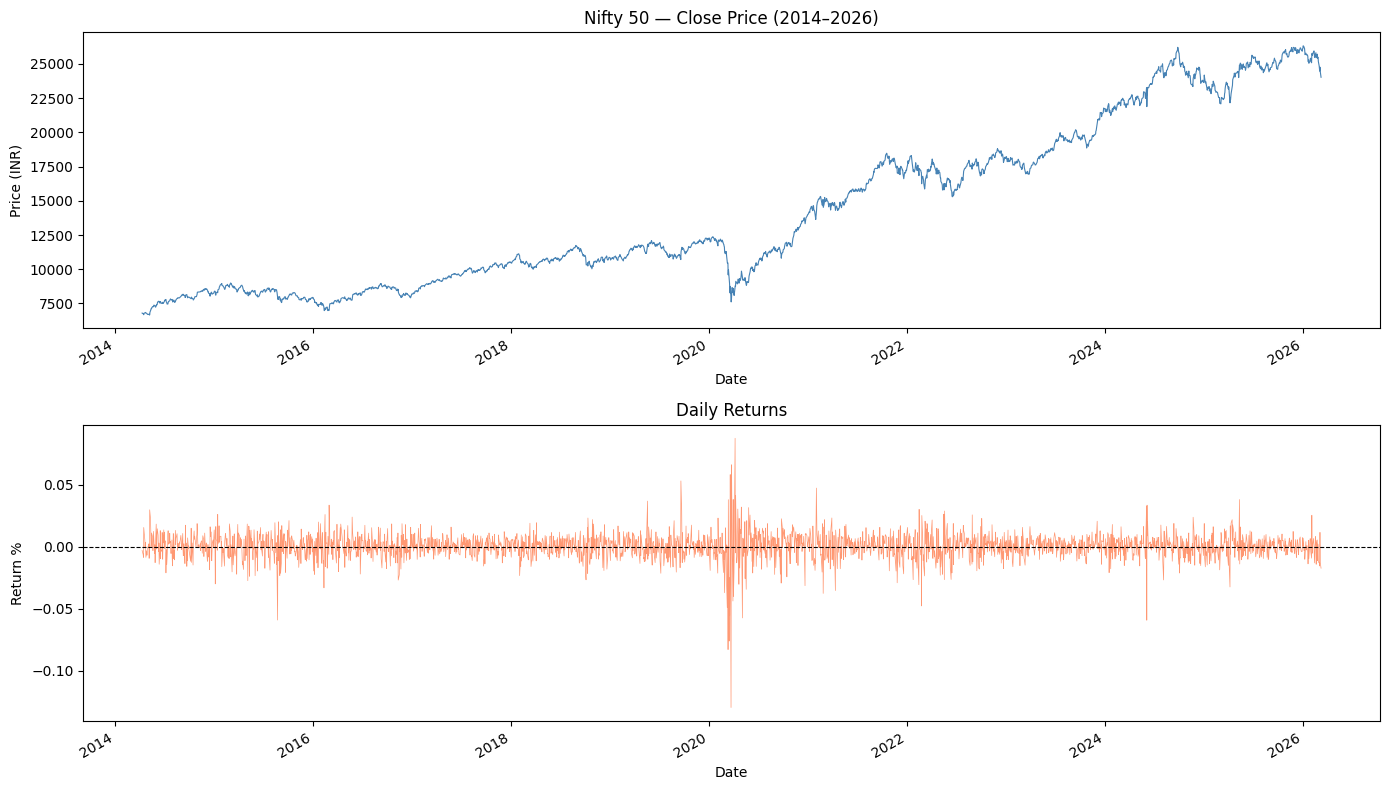

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Raw price
nifty['Close'].plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].set_title('Nifty 50 — Close Price (2014–2026)')
axes[0].set_ylabel('Price (INR)')

# Daily returns — this is price change in % each day
nifty['returns'] = nifty['Close'].pct_change()
nifty['returns'].plot(ax=axes[1], color='coral', linewidth=0.5, alpha=0.8)
axes[1].set_title('Daily Returns')
axes[1].set_ylabel('Return %')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('./output/nifty_overview.png', dpi=150, bbox_inches='tight')
plt.show()

1. What happened to prices around early 2020? What caused it?
- wild loss and gain; covid 19
2. Does the returns chart look stationary compared to the price chart — why?
- because in relative to previous day the gain or loss are small but they get compounded over a large period of time; which explains the advantage of long term trading over day trading
- returns look stationary because they fluctuate around a roughly constant mean (near zero) with roughly constant variance. The price chart has no such constant mean — it just keeps climbing. That's the technical definition of non-stationarity

3. What does the axhline at y=0 represent visually?
- y=0 is the no-change in return data points, ie, from yesterday there was no change

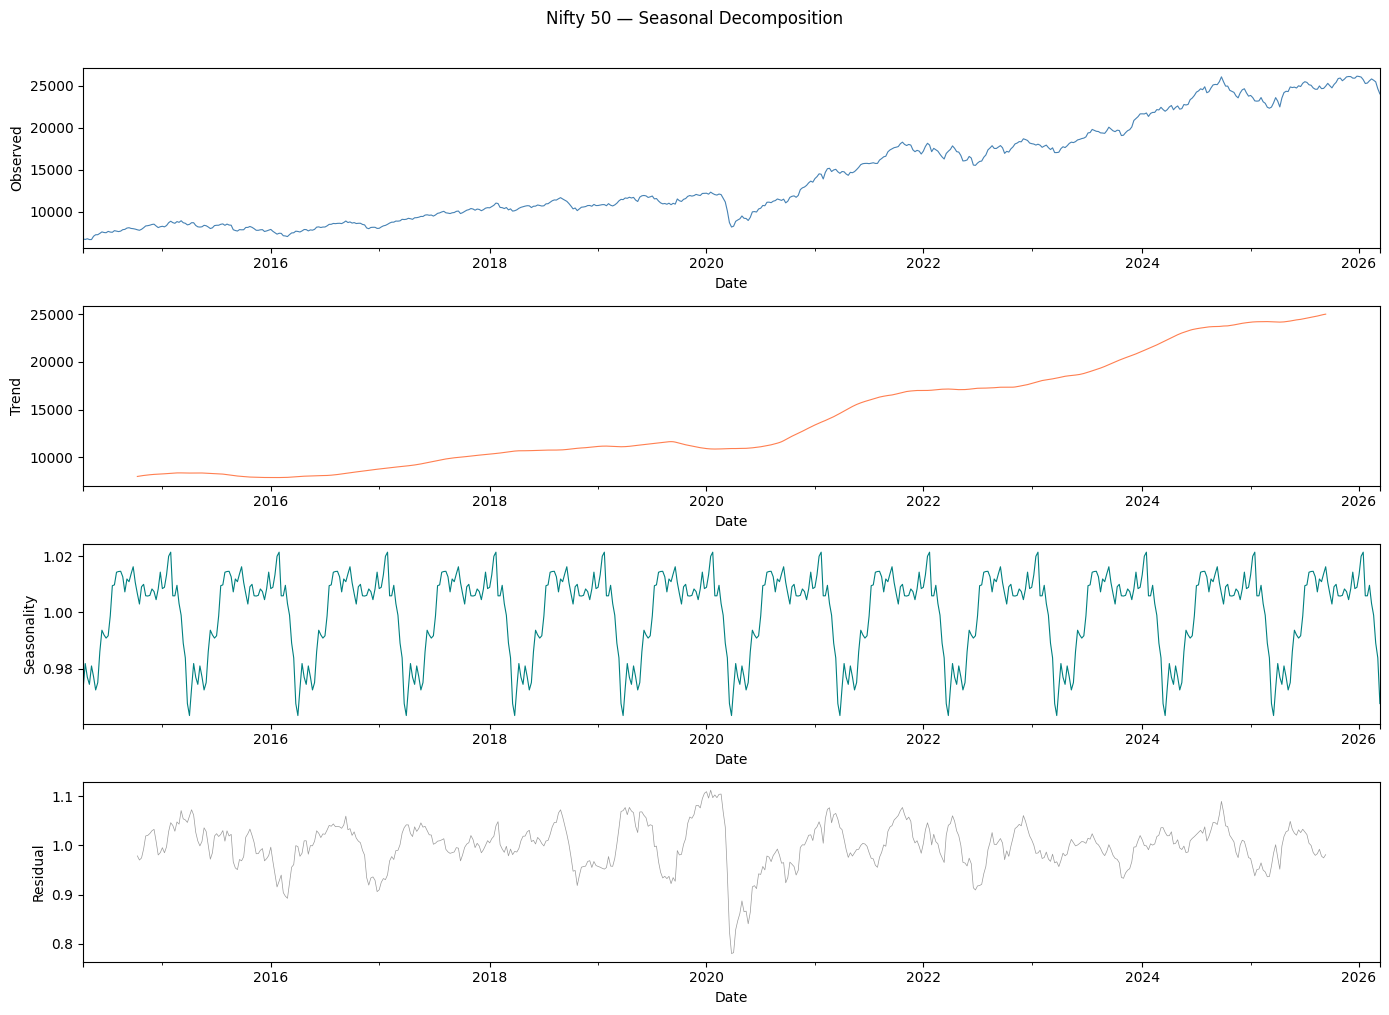

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use weekly frequency — daily is too noisy to see seasonality
nifty_weekly = nifty['Close'].resample('W').mean()

decomposition = seasonal_decompose(nifty_weekly, model='multiplicative', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], linewidth=0.8, color='steelblue')
axes[0].set_ylabel('Observed')

decomposition.trend.plot(ax=axes[1], linewidth=0.8, color='coral')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], linewidth=0.8, color='teal')
axes[2].set_ylabel('Seasonality')

decomposition.resid.plot(ax=axes[3], linewidth=0.5, color='gray', alpha=0.8)
axes[3].set_ylabel('Residual')

plt.suptitle('Nifty 50 — Seasonal Decomposition', y=1.01)
plt.tight_layout()
plt.savefig('./output/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

1. Does the trend component look like what you'd expect from a 12-year Nifty chart?
- yeah, a smooth upward trend
2. Does the seasonality component repeat at a regular interval — or is it irregular?
- yes but explain why cause shouldnt it vary a bit
3. What does a large spike in the residual around 2020 tell you?
- market crashed, it soared as people bought stocks earlier and then when the pandemic hit, stocks were sold and the nifty crashed

In [11]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\nADF Test — {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Conclusion    : ", end="")
    if result[1] <= 0.05:
        print("Stationary (p <= 0.05)")
    else:
        print("NOT stationary (p > 0.05)")

# Test raw price
adf_test(nifty['Close'], 'Raw Close Price')

# Test returns
adf_test(nifty['returns'], 'Daily Returns')


ADF Test — Raw Close Price
  ADF Statistic : -0.1969
  p-value       : 0.9389
  Conclusion    : NOT stationary (p > 0.05)

ADF Test — Daily Returns
  ADF Statistic : -15.1329
  p-value       : 0.0000
  Conclusion    : Stationary (p <= 0.05)


Reading the ADF test:

p-value ≤ 0.05 → stationary → safe to model
p-value > 0.05 → not stationary → needs transformation

ARIMA has three parameters — p, d, q. You need to understand what they mean before you just plug in numbers.

p — how many past values to use as predictors (autoregression)

d — how many times to difference the series to make it stationary. Since returns are already stationary, d=0

q — how many past forecast errors to use as correction (moving average)

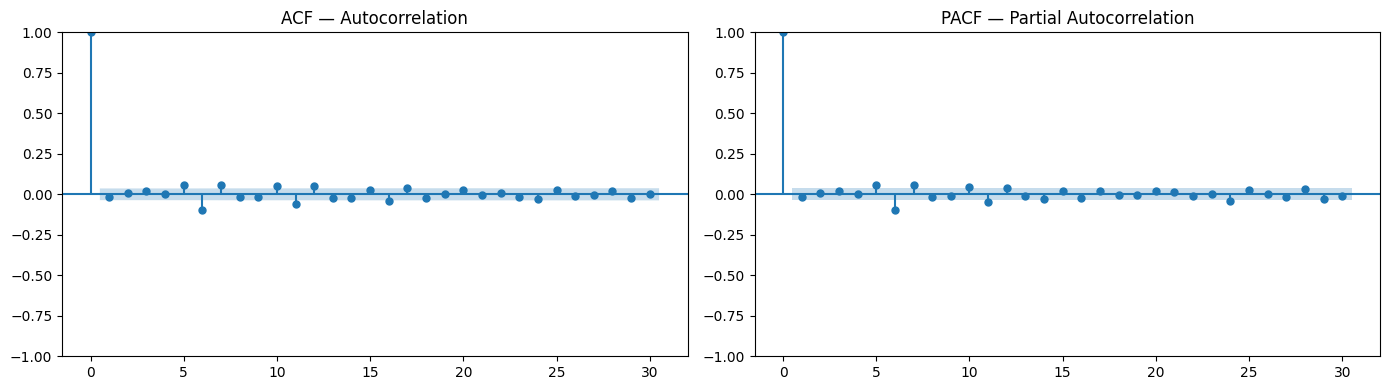

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(nifty['returns'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF — Autocorrelation')

plot_pacf(nifty['returns'].dropna(), lags=30, ax=axes[1])
axes[1].set_title('PACF — Partial Autocorrelation')

plt.tight_layout()
plt.savefig('./output/acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

1. At lag 1 — does yesterday's return significantly predict today's?
- no a lot of it looks random like some are same, some are fliping, some fall sharply
2. How many bars stick outside the confidence band?
- 9

In [13]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Work with returns — already stationary
returns = nifty['returns'].dropna()

# Chronological split — never random for time series
split = int(len(returns) * 0.8)
train = returns.iloc[:split]
test  = returns.iloc[split:]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} rows)")
print(f"Test:  {test.index[0].date()} to {test.index[-1].date()} ({len(test)} rows)")

# ARIMA(1,0,1) — minimal params since ACF showed low autocorrelation
# p=1, d=0 (returns already stationary), q=1
model = ARIMA(train, order=(1, 0, 1))
fitted = model.fit()

print("\nModel summary:")
print(fitted.summary())

Train: 2014-04-11 to 2023-10-20 (2340 rows)
Test:  2023-10-23 to 2026-03-09 (586 rows)


c:\Users\raaji\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\raaji\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\raaji\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Model summary:
                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 2340
Model:                 ARIMA(1, 0, 1)   Log Likelihood                7331.821
Date:                Mon, 16 Mar 2026   AIC                         -14655.643
Time:                        14:06:15   BIC                         -14632.611
Sample:                             0   HQIC                        -14647.253
                               - 2340                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.137      0.033    4.21e-05       0.001
ar.L1          0.2522      0.935      0.270      0.787      -1.580       2.085
ma.L1         -0.2600      0.934    

1. The AIC value — lower is better when comparing models
- -14655.643
2. The p-values for the ar.L1 and ma.L1 coefficients — are they below 0.05?
- no it is 0.787 and 0.787

ar.L1 p-value = 0.787, ma.L1 p-value = 0.781. Both are far above 0.05. That means neither the autoregression term nor the moving average term is statistically significant. The model's parameters are essentially noise — ARIMA found no meaningful pattern to exploit.

MAE:  0.005790
RMSE: 0.008127


c:\Users\raaji\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\raaji\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


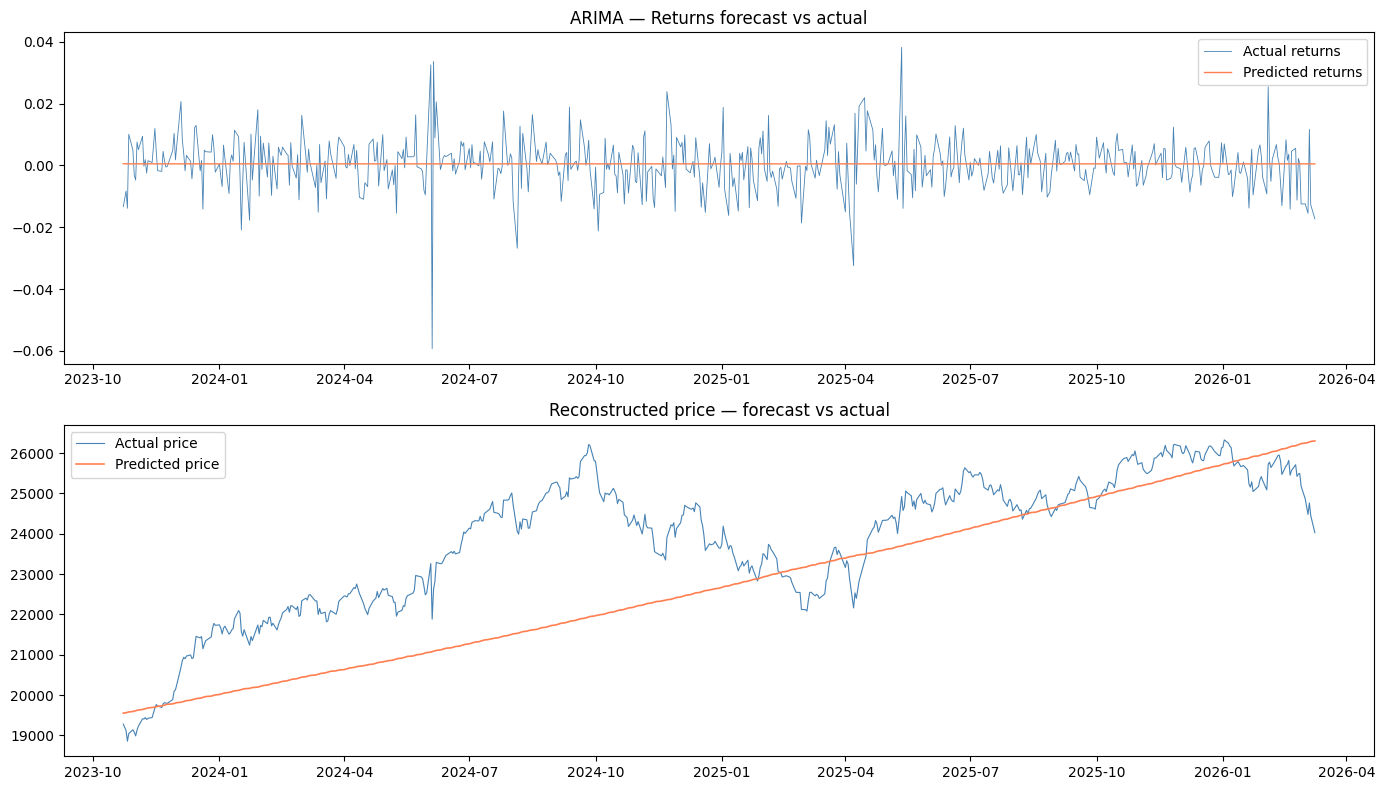

In [14]:
# Forecast on test set
predictions = fitted.predict(start=len(train), 
                              end=len(train) + len(test) - 1)
predictions.index = test.index

# Metrics
mae  = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

# Convert returns forecast back to price
last_train_price = nifty['Close'].iloc[split]
pred_prices  = last_train_price * (1 + predictions).cumprod()
actual_prices = nifty['Close'].iloc[split + 1:]

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Returns forecast
axes[0].plot(test.index, test.values, 
             color='steelblue', linewidth=0.6, label='Actual returns')
axes[0].plot(test.index, predictions.values, 
             color='coral', linewidth=1, label='Predicted returns')
axes[0].set_title('ARIMA — Returns forecast vs actual')
axes[0].legend()

# Price reconstruction
axes[1].plot(actual_prices.index, actual_prices.values,
             color='steelblue', linewidth=0.8, label='Actual price')
axes[1].plot(pred_prices.index, pred_prices.values,
             color='coral', linewidth=1.2, label='Predicted price')
axes[1].set_title('Reconstructed price — forecast vs actual')
axes[1].legend()

plt.tight_layout()
plt.savefig('./output/arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## ARIMA Findings

ARIMA(1,0,1) on Nifty 50 daily returns produced statistically 
insignificant parameters (ar.L1 p=0.787, ma.L1 p=0.781).

The model defaulted to predicting mean drift (~0.05% daily).
This confirms the Efficient Market Hypothesis — past Nifty returns 
have no meaningful autocorrelation and cannot reliably predict 
future returns using ARIMA alone.

The price reconstruction shows the model captures long-term trend 
direction but completely misses short-term volatility.

Conclusion: ARIMA is the wrong tool for stock return forecasting.
Better alternatives: GARCH (for volatility), LSTM (for sequence 
learning), or Prophet (for trend + seasonality decomposition).

In [15]:
print(nifty.index)
print(nifty.columns.tolist())
print(nifty.head(3))
print(nifty.tail(3))
print("Missing:", nifty.isnull().sum())

DatetimeIndex(['2014-04-10', '2014-04-11', '2014-04-15', '2014-04-16',
               '2014-04-17', '2014-04-21', '2014-04-22', '2014-04-23',
               '2014-04-25', '2014-04-28',
               ...
               '2026-02-23', '2026-02-24', '2026-02-25', '2026-02-26',
               '2026-02-27', '2026-03-02', '2026-03-04', '2026-03-05',
               '2026-03-06', '2026-03-09'],
              dtype='datetime64[s]', name='Date', length=2927, freq=None)
['Close', 'returns']
Price             Close   returns
Date                             
2014-04-10  6796.399902       NaN
2014-04-11  6776.299805 -0.002957
2014-04-15  6733.100098 -0.006375
Price              Close   returns
Date                              
2026-03-05  24765.900391  0.011658
2026-03-06  24450.449219 -0.012737
2026-03-09  24028.050781 -0.017276
Missing: Price
Close      0
returns    1
dtype: int64


Download this file for Inflation, consumer prices (annual %) 

https://api.worldbank.org/v2/en/indicator/FP.CPI.TOTL.ZG?downloadformat=csv


In [16]:
import pandas as pd

df_inf = pd.read_csv(
    'API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_84.csv',
    skiprows=4
)

india = df_inf[df_inf['Country Code'] == 'IND']

year_cols = [str(y) for y in range(2014, 2027)]
inflation = india[year_cols].T
inflation.columns = ['inflation']
inflation.index = inflation.index.astype(int)
inflation.index.name = 'year'

print(inflation)

      inflation
year           
2014   6.665657
2015   4.906973
2016   4.948216
2017   3.328173
2018   3.938826
2019   3.729506
2020   6.623437
2021   5.131407
2022   6.699034
2023   5.649143
2024   4.953036
2025   2.800000
2026   3.200000


In [17]:
nifty['year'] = nifty.index.year
nifty = nifty.reset_index()
nifty = nifty.merge(inflation, on='year', how='left')
nifty = nifty.set_index('Date')
nifty.index = pd.to_datetime(nifty.index)
nifty = nifty.drop(columns=['year'])

print(nifty.columns.tolist())
print(nifty.head(3))
print("Missing:", nifty.isnull().sum())

['Close', 'returns', 'inflation']
                  Close   returns  inflation
Date                                        
2014-04-10  6796.399902       NaN   6.665657
2014-04-11  6776.299805 -0.002957   6.665657
2014-04-15  6733.100098 -0.006375   6.665657
Missing: Close        0
returns      1
inflation    0
dtype: int64


Correlation: 0.394
    year  avg_return  inflation
0   2014    0.001178   6.665657
1   2015   -0.000117   4.906973
2   2016    0.000167   4.948216
3   2017    0.001032   3.328173
4   2018    0.000159   3.938826
5   2019    0.000509   3.729506
6   2020    0.000754   6.623437
7   2021    0.000920   5.131407
8   2022    0.000230   6.699034
9   2023    0.000764   5.649143
10  2024    0.000382   4.953036
11  2025    0.000429   2.800000
12  2026   -0.001826   3.200000


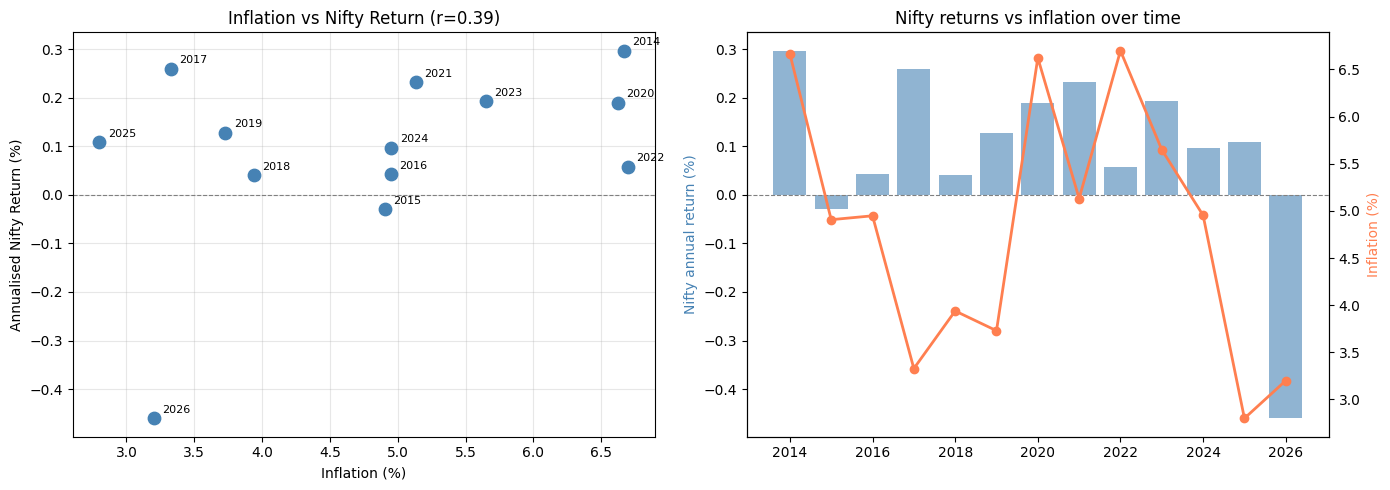

In [18]:
import matplotlib.pyplot as plt

nifty['year'] = nifty.index.year
annual = nifty.groupby('year').agg(
    avg_return=('returns', 'mean'),
    inflation=('inflation', 'first')
).reset_index()

corr = annual['avg_return'].corr(annual['inflation'])
print(f"Correlation: {corr:.3f}")
print(annual)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(annual['inflation'], 
                annual['avg_return'] * 252,
                color='steelblue', s=80, zorder=3)
for _, row in annual.iterrows():
    axes[0].annotate(str(int(row['year'])),
                     (row['inflation'], row['avg_return'] * 252),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[0].axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Inflation (%)')
axes[0].set_ylabel('Annualised Nifty Return (%)')
axes[0].set_title(f'Inflation vs Nifty Return (r={corr:.2f})')
axes[0].grid(True, alpha=0.3)

# Timeline
ax2 = axes[1]
ax3 = ax2.twinx()
ax2.bar(annual['year'], annual['avg_return'] * 252,
        alpha=0.6, color='steelblue', label='Nifty return %')
ax3.plot(annual['year'], annual['inflation'],
         color='coral', linewidth=2, marker='o', label='Inflation %')
ax2.set_title('Nifty returns vs inflation over time')
ax2.set_ylabel('Nifty annual return (%)', color='steelblue')
ax3.set_ylabel('Inflation (%)', color='coral')
ax2.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('./output/inflation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up helper column
nifty = nifty.drop(columns=['year'])

1. Is correlation positive or negative — does higher inflation mean better or worse Nifty returns?
- better
2. Look at 2020 on the bar chart — high inflation year, what happened to Nifty returns?
- it performed well
3. Is this relationship strong enough to be a useful predictor in a model?
- i dont think so, the irratic nature of inflation makes it difficult to juse, look at 2017-2027 or even 2022-2025 it all looks ever irregular

## Phase 3 Summary

**Data:** Nifty 50 daily close prices, 2014–2026 (2927 rows)

**Stationarity:** Raw prices failed ADF test (p=0.94). 
Daily returns passed (p=0.00). Returns used for modelling.

**Decomposition:** Clear upward trend across 12 years. 
Weak annual seasonality — likely mathematical artifact 
not genuine market pattern.

**ARIMA(1,0,1):** Parameters statistically insignificant 
(p=0.787, p=0.781). Model defaulted to mean drift prediction.
Confirms EMH — past returns don't predict future returns.

**Inflation:** Weak positive correlation with Nifty returns 
(r=0.39, n=12). Relationship too unstable to be a reliable 
standalone predictor. Useful as context, not as a feature.

**Key learning:** A model that honestly reports it found 
nothing is more valuable than one that overfits noise.